# World Happiness Report : Data Wrangling Pipeline

This notebook documents the journey of our dataset from raw data collection through to a validated, analysis-ready CSV.

**Structure:**
1. **Dataset Creation** : Load the Kaggle happiness data, add World Bank indicators, and merge into a single panel dataset.
2. **Discovery & Profiling** : Examine shapes, types, distributions, and missingness before making any changes.
3. **Data Cleaning** : Standardise column names, handle missing values, remove duplicates.
4. **Data Structuring** : Enforce correct dtypes, reorder columns logically.
5. **Data Validation** : Range checks, final null audit, and summary.

---
---
# Part 0: Dataset Creation

The World Happiness Report CSV gives us country-year happiness scores, but we want to add socioeconomic indicators from the World Bank to gain more insights, so let's do that before we start wrangling.

**Steps:**
1. Load the happiness data and convert country names into ISO3 codes so we can use the World Bank API
2. Choose World Bank indicators across multiple themes (economy, health, education, governance, infrastructure, labour)
3. Fetch data from the World Bank API
4. Merge everything into a single dataset
5. Perform initial quality fixes (fill in missing regions)

## 0.1 Imports & Setup

`missing_report` gives a quick view of which columns have missing data and how bad it is.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import country_converter as coco
from HZ_WH_helper_functions import missing_report
from HZ_WH_helper_functions import fetch_wb

pd.set_option('display.float_format', '{:.3f}'.format)

## 0.2 Load the Happiness Dataset

In [35]:
happiness_df = pd.read_csv('drafts/datasets/world_happiness_report.csv')

print(f'Shape: {happiness_df.shape}')
print(f'Countries: {happiness_df["Country Name"].nunique()}')
happiness_df.head()

Shape: (2199, 13)
Countries: 165


,Country Name,Regional Indicator,Year,Life Ladder,Log GDP Per Capita,Social Support,Healthy Life Expectancy At Birth,Freedom To Make Life Choices,Generosity,Perceptions Of Corruption,Positive Affect,Negative Affect,Confidence In National Government
0,Afghanistan,South Asia,2008,3.724,7.350,0.451,50.500,0.718,0.168,0.882,0.414,0.258,0.612
1,Afghanistan,South Asia,2009,4.402,7.509,0.552,50.800,0.679,0.191,0.850,0.481,0.237,0.612
2,Afghanistan,South Asia,2010,4.758,7.614,0.539,51.100,0.600,0.121,0.707,0.517,0.275,0.299
3,Afghanistan,South Asia,2011,3.832,7.581,0.521,51.400,0.496,0.164,0.731,0.480,0.267,0.307
4,Afghanistan,South Asia,2012,3.783,7.661,0.521,51.700,0.531,0.238,0.776,0.614,0.268,0.435


## 0.3 Convert Country Names -> ISO3 Codes

We need standardised country codes so we can join the happiness data with World Bank data. The `country_converter` library handles the messy name-matching for us.

In [36]:
cc = coco.CountryConverter()

unique_countries = happiness_df['Country Name'].unique()
iso3_series = cc.pandas_convert(pd.Series(unique_countries), to='ISO3')

# 'not found' -> NaN so they don't break API calls later on
iso3_series = iso3_series.replace('not found', np.nan)

iso_map = dict(zip(unique_countries, iso3_series))
happiness_df['ISO3'] = happiness_df['Country Name'].map(iso_map)

not_found = happiness_df.loc[happiness_df['ISO3'].isna(), 'Country Name'].unique()
print(f'Countries not converted to ISO3: {len(not_found)}')
if len(not_found):
    print(not_found)

Countries not converted to ISO3: 0


## 0.4 Define World Bank Indicators

We pull indicators across six themes that theoretically explain happiness:
- **Wealth & Economy** : income, inflation, trade
- **Health** : life expectancy, child mortality, health spending
- **Education** : expected years of schooling
- **Infrastructure** : internet, electricity, urbanisation
- **Labour & Social** : unemployment, female participation, population
- **Governance** (WGI) : corruption, rule of law, political stability

In [37]:
WB_INDICATORS = {
    # --- Wealth & Economy ---
    'NY.GDP.PCAP.CD':       'GDP/Capita',
    'NY.GDP.MKTP.KD.ZG':    'GDP Growth Rate',
    'FP.CPI.TOTL.ZG':       'Inflation Rate',
    'NE.TRD.GNFS.ZS':       'Trade Openness',

    # --- Health ---
    'SP.DYN.LE00.IN':       'Life Expectancy',
    'SH.DYN.MORT':          'Child Mortality Rate',
    'SH.XPD.CHEX.GD.ZS':    'Health Expenditure pct of GDP',
    'SH.XPD.OOPC.CH.ZS':    'Out Of Pocket Health pct',

    # --- Education ---
    'SE.COM.DURS':          'Expected Years Of Schooling',

    # --- Infrastructure & Modernisation ---
    'IT.NET.USER.ZS':       'Internet Penetration',
    'EG.ELC.ACCS.ZS':       'Electricity Access pct',
    'SP.URB.TOTL.IN.ZS':    'Urbanization Rate',
    'IS.ROD.PAVE.ZS':       'Paved Roads pct',

    # --- Labour & Social ---
    'SL.UEM.TOTL.ZS':       'Unemployment Rate',
    'SL.TLF.CACT.FE.ZS':    'Female Labor Participation',
    'SP.POP.TOTL':          'Population',
    'SP.POP.GROW':          'Population Growth Rate',
}

# Governance indicators come from a different World Bank database (WGI = db 3)
WGI_INDICATORS = {
    'CC.EST':  'Control Of Corruption',
    'GE.EST':  'Govt Effectiveness',
    'RL.EST':  'Rule Of Law',
    'VA.EST':  'Voice Accountability',
    'PV.EST':  'Political Stability',
    'RQ.EST':  'Regulatory Quality',
}

print(f'Total WDI indicators: {len(WB_INDICATORS)}')
print(f'Total WGI indicators: {len(WGI_INDICATORS)}')

Total WDI indicators: 17
Total WGI indicators: 6


## 0.5 Fetch World Bank Data

The World Bank API is slow; a full fetch takes 10-30 minutes and usually fails mid-fetch. 

Rather than make this notebook grind to a halt, we ran the fetch separately using `fetch_world_bank.py`, and saved the raw outputs to `wdi_raw.csv` and `wgi_raw.csv`.

Below is the fetch code for reference (commented out). The cell that actually runs loads the pre-fetched CSVs is below it.

> To re-fetch from scratch: go to `HZ_WH_helper_functions.py`, read its instructions, run it, then re-run this notebook.

In [38]:
# this does work, but it takes forever to run, so i suggest you work with the already imported csv's in the cell below

# years = sorted(happiness_df['Year'].unique())
# iso3_list = happiness_df['ISO3'].dropna().unique().tolist()
# wdi_keys = list(WB_INDICATORS.keys())
# wgi_keys = list(WGI_INDICATORS.keys())
#
# print(f'Fetching data for {len(iso3_list)} countries, years {years[0]}-{years[-1]}')
#
# df_wdi = fetch_wb(iso3_list, years, wdi_keys, batch_size=6)
# df_wgi = fetch_wb(iso3_list, years, wgi_keys, db_type=2)
#
# df_wdi.to_csv('drafts/datasets/wdi_raw.csv', index=False)
# df_wgi.to_csv('drafts/datasets/wgi_raw.csv', index=False)

In [39]:
# -- Load the pre-fetched World Bank data --
df_wdi = pd.read_csv('drafts/datasets/wdi_raw.csv')
df_wgi = pd.read_csv('drafts/datasets/wgi_raw.csv')

print(f'WDI: {df_wdi.shape[0]:,} rows * {df_wdi.shape[1]} cols')
print(f'WGI: {df_wgi.shape[0]:,} rows * {df_wgi.shape[1]} cols')

WDI: 2,608 rows * 20 cols
WGI: 978 rows * 20 cols


## 0.6 Merge & Reshape

The World Bank API returns data in wide format (`ISO3 | series/indicator | YR2015 | YR2016 | ...`), but it'll be easier to work with if the columns were the indicators. We melt it into long format, pivot so each indicator becomes its own column, then merge with the happiness data to create the df we will be working with for the rest of the notebook.

In [40]:
def melt_and_pivot(df):
    """
    Convert WB wide format  (ISO3 | series | YR2015 | YR2016 | ...)
    to analysis-ready wide  (ISO3 | Year   | indicator1 | indicator2 | ...).
    """
    year_cols = [c for c in df.columns if c not in ('ISO3', 'series')]
    long = df.melt(id_vars=['ISO3', 'series'], value_vars=year_cols,
                   var_name='Year', value_name='value')
    # Normalise year strings: 'YR2015' or '2015' -> int
    long['Year'] = long['Year'].str.extract(r'(\d+)', expand=False).astype(int)
    long = long.dropna(subset=['value'])
    pivot = (
        long.pivot_table(index=['ISO3', 'Year'], columns='series',
                         values='value', aggfunc='first')
            .reset_index()
    )
    pivot.columns.name = None
    return pivot


wdi_pivot = melt_and_pivot(df_wdi)
wgi_pivot = melt_and_pivot(df_wgi)
df_wb = pd.merge(wdi_pivot, wgi_pivot, on=['ISO3', 'Year'], how='outer')

# wb data returns with indicator codes as column names instead of human-readable labels, 
# so let's rename the columns using the mapping dicts we already have
rename_map = {**WB_INDICATORS, **WGI_INDICATORS}
df_wb.rename(columns=rename_map, inplace=True)

# Merge with happiness data
df = pd.merge(happiness_df, df_wb, on=['ISO3', 'Year'], how='left')

print(f'Merged shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Merged shape: (2199, 36)
Columns: ['Country Name', 'Regional Indicator', 'Year', 'Life Ladder', 'Log GDP Per Capita', 'Social Support', 'Healthy Life Expectancy At Birth', 'Freedom To Make Life Choices', 'Generosity', 'Perceptions Of Corruption', 'Positive Affect', 'Negative Affect', 'Confidence In National Government', 'ISO3', 'Electricity Access pct', 'Inflation Rate', 'Internet Penetration', 'Trade Openness', 'GDP Growth Rate', 'GDP/Capita', 'Expected Years Of Schooling', 'Child Mortality Rate', 'Health Expenditure pct of GDP', 'Out Of Pocket Health pct', 'Female Labor Participation', 'Unemployment Rate', 'Life Expectancy', 'Population Growth Rate', 'Population', 'Urbanization Rate', 'Control Of Corruption', 'Govt Effectiveness', 'Political Stability', 'Rule Of Law', 'Regulatory Quality', 'Voice Accountability']


,Country Name,Regional Indicator,Year,Life Ladder,Log GDP Per Capita,Social Support,Healthy Life Expectancy At Birth,Freedom To Make Life Choices,Generosity,Perceptions Of Corruption,...,Life Expectancy,Population Growth Rate,Population,Urbanization Rate,Control Of Corruption,Govt Effectiveness,Political Stability,Rule Of Law,Regulatory Quality,Voice Accountability
0,Afghanistan,South Asia,2008,3.724,7.350,0.451,50.500,0.718,0.168,0.882,...,59.708,2.187,26482622.000,21.124,-1.672,-1.528,-2.691,-1.903,-1.607,-1.169
1,Afghanistan,South Asia,2009,4.402,7.509,0.552,50.800,0.679,0.191,0.850,...,60.248,3.646,27466101.000,21.689,-1.552,-1.508,-2.711,-1.876,-1.665,-1.375
2,Afghanistan,South Asia,2010,4.758,7.614,0.539,51.100,0.600,0.121,0.707,...,60.702,2.935,28284089.000,22.261,-1.645,-1.478,-2.579,-1.870,-1.517,-1.404
3,Afghanistan,South Asia,2011,3.832,7.581,0.521,51.400,0.496,0.164,0.731,...,61.250,3.692,29347708.000,22.821,-1.600,-1.474,-2.502,-1.923,-1.536,-1.336
4,Afghanistan,South Asia,2012,3.783,7.661,0.521,51.700,0.531,0.238,0.776,...,61.735,4.048,30560034.000,23.343,-1.430,-1.376,-2.419,-1.652,-1.193,-1.267


## 0.7 Initial Quality Fix: Region Assignment

Some countries in the happiness dataset are missing their `Regional Indicator`. Since this is a metadata field that we know the correct values for, we fix it here at creation time rather than during the cleaning stage.

In [41]:
regions_missing_count = df['Regional Indicator'].isnull().sum()
regions_missing = df[df['Regional Indicator'].isnull()]
missing_countries = regions_missing['Country Name'].unique()

print(f"Countries with missing regions: {len(missing_countries)}")
print(f"List of countries: {missing_countries}")
print(f"Total rows missing a region: {regions_missing_count}")

Countries with missing regions: 21
List of countries: ['Angola' 'Belize' 'Bhutan' 'Central African Republic' 'Congo (Kinshasa)'
 'Cuba' 'Czechia' 'Djibouti' 'Eswatini' 'Guyana' 'Oman' 'Qatar' 'Somalia'
 'Somaliland region' 'South Sudan' 'State of Palestine' 'Sudan' 'Suriname'
 'Syria' 'Trinidad and Tobago' 'Turkiye']
Total rows missing a region: 112


In [42]:
# Fill missing Regional Indicator values using a manual lookup
manual_region_map = {
    "Angola": "Sub-Saharan Africa",
    "Belize": "Latin America and Caribbean",
    "Bhutan": "South Asia",
    "Central African Republic": "Sub-Saharan Africa",
    "Congo (Kinshasa)": "Sub-Saharan Africa",
    "Cuba": "Latin America and Caribbean",
    "Czechia": "Central and Eastern Europe",
    "Djibouti": "Sub-Saharan Africa",
    "Guyana": "Latin America and Caribbean",
    # WB classifies Israel as Middle East and North Africa, but it's more commonly grouped with Western Europe in other datasets
    "Israel": "Western Europe",  
    "Oman": "Middle East and North Africa",
    "State of Palestine": "Middle East and North Africa",
    "Qatar": "Middle East and North Africa",
    "Sudan": "Sub-Saharan Africa",
    "Somaliland region": "Sub-Saharan Africa",
    "Somalia": "Sub-Saharan Africa",
    "South Sudan": "Sub-Saharan Africa",
    "Suriname": "Latin America and Caribbean",
    "Eswatini": "Sub-Saharan Africa",
    "Syria": "Middle East and North Africa",
    "Trinidad and Tobago": "Latin America and Caribbean",
    "Turkiye": "Middle East and North Africa",
}

df['Regional Indicator'] = df.apply(
    lambda row: manual_region_map.get(row['Country Name'], row['Regional Indicator']),
    axis=1 # so it iterates over rows, not columns
)

regions_missing = df['Regional Indicator'].isnull().sum()
print(f"Regions still missing after manual assignment: {regions_missing}")
if regions_missing > 0:
    print("Countries still missing:", df[df['Regional Indicator'].isnull()]['Country Name'].unique())

Regions still missing after manual assignment: 0


---
# Part 1: Data Discovery & Profiling

Now that the dataset exists, we profile it *before touching anything*. This answers:
- How many rows and columns?
- What are the data types? Are the numeric columns actually numeric?
- Which columns have missing values, and how severe is it?
- What do the distributions look like, how are the outliers & tails?

We observe and document here. No modifications.

In [43]:
# loot at shape and dtypes
print(f"Shape: {df.shape[0]:,} rows * {df.shape[1]} columns")
print(f"\nColumn names and dtypes:")
print(df.dtypes.to_string())
df.head()

# all seems to be in order

Shape: 2,199 rows * 36 columns

Column names and dtypes:
Country Name                          object
Regional Indicator                    object
Year                                   int64
Life Ladder                          float64
Log GDP Per Capita                   float64
Social Support                       float64
Healthy Life Expectancy At Birth     float64
Freedom To Make Life Choices         float64
Generosity                           float64
Perceptions Of Corruption            float64
Positive Affect                      float64
Negative Affect                      float64
Confidence In National Government    float64
ISO3                                  object
Electricity Access pct               float64
Inflation Rate                       float64
Internet Penetration                 float64
Trade Openness                       float64
GDP Growth Rate                      float64
GDP/Capita                           float64
Expected Years Of Schooling          float6

,Country Name,Regional Indicator,Year,Life Ladder,Log GDP Per Capita,Social Support,Healthy Life Expectancy At Birth,Freedom To Make Life Choices,Generosity,Perceptions Of Corruption,...,Life Expectancy,Population Growth Rate,Population,Urbanization Rate,Control Of Corruption,Govt Effectiveness,Political Stability,Rule Of Law,Regulatory Quality,Voice Accountability
0,Afghanistan,South Asia,2008,3.724,7.350,0.451,50.500,0.718,0.168,0.882,...,59.708,2.187,26482622.000,21.124,-1.672,-1.528,-2.691,-1.903,-1.607,-1.169
1,Afghanistan,South Asia,2009,4.402,7.509,0.552,50.800,0.679,0.191,0.850,...,60.248,3.646,27466101.000,21.689,-1.552,-1.508,-2.711,-1.876,-1.665,-1.375
2,Afghanistan,South Asia,2010,4.758,7.614,0.539,51.100,0.600,0.121,0.707,...,60.702,2.935,28284089.000,22.261,-1.645,-1.478,-2.579,-1.870,-1.517,-1.404
3,Afghanistan,South Asia,2011,3.832,7.581,0.521,51.400,0.496,0.164,0.731,...,61.250,3.692,29347708.000,22.821,-1.600,-1.474,-2.502,-1.923,-1.536,-1.336
4,Afghanistan,South Asia,2012,3.783,7.661,0.521,51.700,0.531,0.238,0.776,...,61.735,4.048,30560034.000,23.343,-1.430,-1.376,-2.419,-1.652,-1.193,-1.267


In [44]:
# Statistical summary
print(df.describe())

"""
A few observations here:
* Genorosity's mean is 0, which means that people are donating roughly as much as you'd expect given how rich their country is
* Most people around the world think their government is corrupt
* A few massive countries like China and India are skewing population statistics, maing the mean much higher than the median
* For Healthy life expectancy, the lowest value in the data (6.72 years) seems suspiciously wrong
* The variables with the most gaps (Generosity, Corruption, Life Expectancy) will be checked in step 2 if the missing entries 
  are scattered or clustered in particular countries or time periods.
"""

          Year  Life Ladder  Log GDP Per Capita  Social Support  \
count 2199.000     2199.000            2179.000        2186.000   
mean  2014.161        5.479               9.390           0.811   
std      4.719        1.126               1.153           0.121   
min   2005.000        1.281               5.527           0.228   
25%   2010.000        4.647               8.500           0.747   
50%   2014.000        5.432               9.499           0.836   
75%   2018.000        6.309              10.373           0.905   
max   2022.000        8.019              11.664           0.987   

       Healthy Life Expectancy At Birth  Freedom To Make Life Choices  \
count                          2145.000                      2166.000   
mean                             63.295                         0.748   
std                               6.901                         0.140   
min                               6.720                         0.258   
25%                            

"\nA few observations here:\n* Genorosity's mean is 0, which means that people are donating roughly as much as you'd expect given how rich their country is\n* Most people around the world think their government is corrupt\n* A few massive countries like China and India are skewing population statistics, maing the mean much higher than the median\n* For Healthy life expectancy, the lowest value in the data (6.72 years) seems suspiciously wrong\n* The variables with the most gaps (Generosity, Corruption, Life Expectancy) will be checked in step 2 if the missing entries \n  are scattered or clustered in particular countries or time periods.\n"

In [45]:
# After seeing the variations between counts in the columns, Missing values report
print(f"Columns with missing values: {df.isnull().any().sum()} of {df.shape[1]}")
print(f"Total missing cells: {df.isnull().sum().sum():,}\n")
missing_report(df)

Columns with missing values: 31 of 36
Total missing cells: 1,547



,missing_count,missing_pct
Confidence In National Government,361,16.420
Perceptions Of Corruption,116,5.280
Expected Years Of Schooling,116,5.280
Trade Openness,113,5.140
Inflation Rate,81,3.680
Generosity,73,3.320
Internet Penetration,71,3.230
Health Expenditure pct of GDP,70,3.180
Out Of Pocket Health pct,70,3.180
Healthy Life Expectancy At Birth,54,2.460


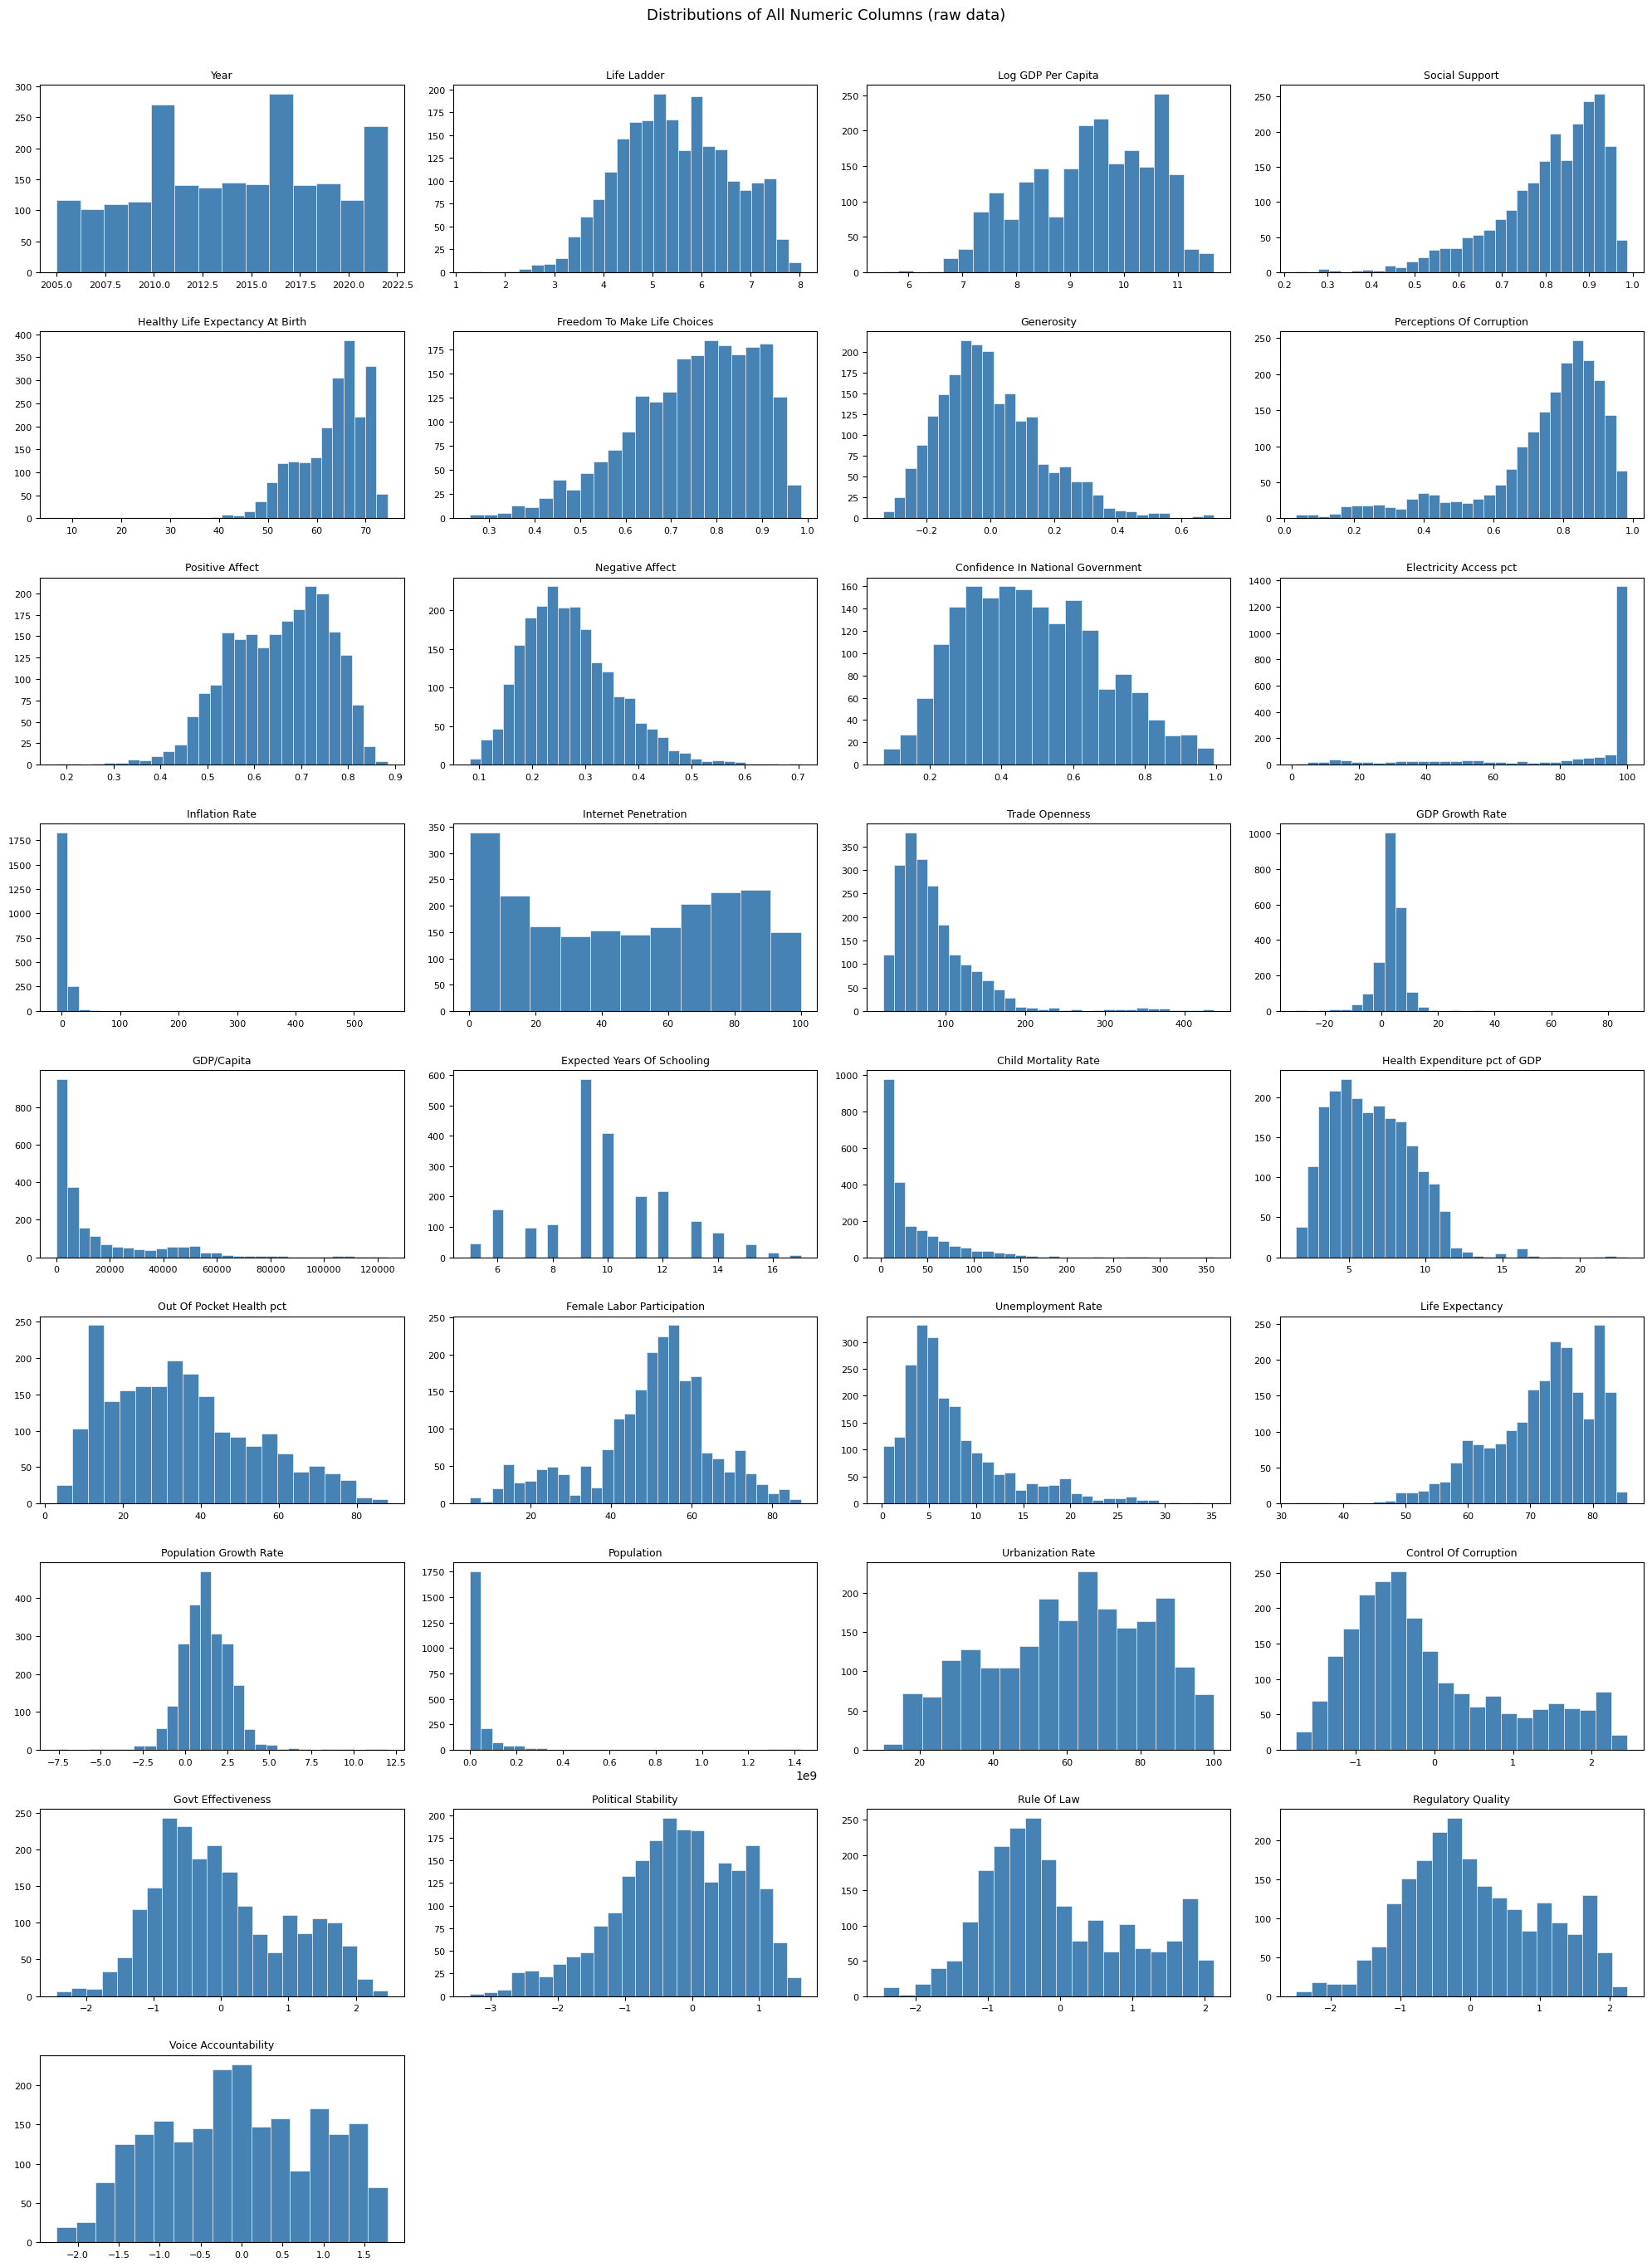

In [46]:
# Histograms for all numeric columns
num_cols = df.select_dtypes(include='number').columns.tolist()
graphs_per_row = 4
row_count = math.ceil(len(num_cols) / graphs_per_row)

fig, axes = plt.subplots(row_count, graphs_per_row, figsize=(20, row_count * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    optimal_bins = min(30, len(np.histogram_bin_edges(df[col].dropna(), bins='fd')) - 1)
    axes[i].hist(df[col].dropna(), bins=optimal_bins, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions of All Numeric Columns (raw data)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Distribution Insights
- **Inflation Rate, GDP/Capita, Population, Child Mortality Rate** - heavily right-skewed, log transformations planned before modeling
- **Internet Penetration, Female Labor Participation, Urbanization Rate** - bimodal, reflecting the developed/developing world divide; may model separately
- **Electricity Access** - massive spike at 100%, limits its usefulness as a coefficient
- **GDP Growth Rate** - extreme outliers on both ends, consider winsorizing
- **Expected Years of Schooling** - stepped/chunky distribution, worth checking source methodology
- **Perceptions of Corruption** - skews heavily toward high values, as previously noted



---
# Part 2: Data Cleaning

Based on the profiling above, we apply the following cleaning steps in order:

1. **Remove duplicate rows** as duplicates  introduce biases to the analysis and future models.
2. **Per-country linear interpolation**, fills interior gaps using each country's own time series, with forward/backward fill for edge years.
3. **Drop remaining rows with nulls** - any rows that interpolation couldn't fill are removed.

> **Limitation:** Linear interpolation assumes smooth change between known data points. This is reasonable for slow-moving indicators (life expectancy, urbanisation) but may understate volatility in fast-changing ones like inflation rate or GDP growth. We acknowledge this trade-off, but alternatives like mean imputation would ignore the country's trajectory entirely, which is arguably worse for the data's accuracy.

In [47]:
# Remove duplicate rows
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")
if n_dupes > 0:
    df = df.drop_duplicates()
    print(f"Removed. Remaining rows: {len(df):,}")

print()
# Missing data snapshot
print(f"Rows with at least one missing value: {df.isnull().any(axis=1).sum()} of {len(df)}")
print()
missing_report(df)

Duplicate rows found: 0

Rows with at least one missing value: 660 of 2199



,missing_count,missing_pct
Confidence In National Government,361,16.420
Perceptions Of Corruption,116,5.280
Expected Years Of Schooling,116,5.280
Trade Openness,113,5.140
Inflation Rate,81,3.680
Generosity,73,3.320
Internet Penetration,71,3.230
Health Expenditure pct of GDP,70,3.180
Out Of Pocket Health pct,70,3.180
Healthy Life Expectancy At Birth,54,2.460


In [48]:
# Per-country linear interpolation for numeric columns
# This uses each country's own time series to fill gaps - better than a global statistic
# for panel data, though it assumes smooth transitions between known points.
df = df.sort_values(['ISO3', 'Year']).reset_index(drop=True)

interp_cols = [
    c for c in df.select_dtypes(include='number').columns
    if c != 'Year'
]

df[interp_cols] = (
    df.groupby('ISO3')[interp_cols]
      .transform(lambda g: g.interpolate(method='linear').ffill().bfill())
)

print()
# Missing data snapshot
print(f"Rows with at least one missing value: {df.isnull().any(axis=1).sum()} of {len(df)}")
print()
missing_report(df)


Rows with at least one missing value: 302 of 2199



,missing_count,missing_pct
Confidence In National Government,130,5.910
Expected Years Of Schooling,102,4.640
Trade Openness,74,3.370
Health Expenditure pct of GDP,43,1.960
Out Of Pocket Health pct,43,1.960
Inflation Rate,33,1.500
Female Labor Participation,31,1.410
Electricity Access pct,31,1.410
Unemployment Rate,31,1.410
Perceptions Of Corruption,29,1.320


In [50]:
# Drop rows that still have missing values after interpolation
before = len(df)
df = df.dropna()
dropped = before - len(df)
if dropped > 0:
    print(f"Dropped {dropped} row(s) with remaining nulls.")
else:
    print("No rows dropped - all values filled.")
print(f"Shape after cleaning: {df.shape}")

print()
# Missing data snapshot
print(f"Rows with at least one missing value: {df.isnull().any(axis=1).sum()} of {len(df)}")

No rows dropped - all values filled.
Shape after cleaning: (1897, 36)

Rows with at least one missing value: 0 of 1897


---
# Part 3: Data Structuring & Integration

### Structuring
Structuring involves standardising encoding and using Pandas to filter or select columns. In our case, encoding was already handled during dataset creation - the World Bank indicator codes were mapped to human-readable names using the `WB_INDICATORS` and `WGI_INDICATORS` dictionaries (see Section 0.6). No additional encoding or column filtering is needed here.

### Integration
Integration involves merging datasets on shared columns, grouping by criteria, or appending data vertically. Our dataset was assembled in Part 0 by merging the World Happiness Report with two World Bank sources (WDI and WGI) on `ISO3` and `Year`. Since this had to happen before cleaning - so we could profile and clean the full dataset in one place - no further integration steps are required here. The data is already sorted alphabetically by country and chronologically by year.

What we *can* do in this stage is enforce correct data types and ensure the column order is logical for downstream analysis.

In [51]:
# Ensure Year is integer
df['Year'] = df['Year'].astype(int)
print(f"Year dtype: {df['Year'].dtype}")
print(f"Year range: {df['Year'].min()} - {df['Year'].max()}")

Year dtype: int64
Year range: 2005 - 2022


In [52]:
# Reorder columns: identifiers -> happiness metrics -> World Bank indicators
id_cols = ['Country Name', 'ISO3', 'Regional Indicator', 'Year']

happiness_cols = [
    'Life Ladder', 'Log GDP Per Capita', 'Social Support',
    'Healthy Life Expectancy At Birth', 'Freedom To Make Life Choices',
    'Generosity', 'Perceptions Of Corruption', 'Positive Affect',
    'Negative Affect', 'Confidence In National Government'
]

# Everything else is a World Bank indicator
wb_cols = [c for c in df.columns if c not in id_cols + happiness_cols]

# Order the columns
ordered = [c for c in id_cols + happiness_cols + wb_cols if c in df.columns]
df = df[ordered]

print(f"Final column order ({len(ordered)} columns):")
print(f"  Identifiers    : {id_cols}")
print(f"  Happiness cols : {[c for c in happiness_cols if c in df.columns]}")
print(f"  World Bank cols: {wb_cols}")

Final column order (36 columns):
  Identifiers    : ['Country Name', 'ISO3', 'Regional Indicator', 'Year']
  Happiness cols : ['Life Ladder', 'Log GDP Per Capita', 'Social Support', 'Healthy Life Expectancy At Birth', 'Freedom To Make Life Choices', 'Generosity', 'Perceptions Of Corruption', 'Positive Affect', 'Negative Affect', 'Confidence In National Government']
  World Bank cols: ['Electricity Access pct', 'Inflation Rate', 'Internet Penetration', 'Trade Openness', 'GDP Growth Rate', 'GDP/Capita', 'Expected Years Of Schooling', 'Child Mortality Rate', 'Health Expenditure pct of GDP', 'Out Of Pocket Health pct', 'Female Labor Participation', 'Unemployment Rate', 'Life Expectancy', 'Population Growth Rate', 'Population', 'Urbanization Rate', 'Control Of Corruption', 'Govt Effectiveness', 'Political Stability', 'Rule Of Law', 'Regulatory Quality', 'Voice Accountability']


In [53]:
# Drop rows where Life Ladder (target variable) is null
before = len(df)
df = df.dropna(subset=['Life Ladder'])
dropped_rows = before - len(df)

if dropped_rows > 0:
    print(f"Dropped {dropped_rows} row(s) with null Life Ladder.")
else:
    print("No rows dropped - Life Ladder is fully populated.")
print(f"Remaining rows: {len(df):,}")

No rows dropped - Life Ladder is fully populated.
Remaining rows: 1,897


---
# Part 4: Data Validation

Cleaning alone isn't enough - we verify the data makes sense before analysis.

Checks:
- **Value ranges**: `Life Ladder` is a 0-10 Cantril scale; percentages must be 0-100; survey columns are 0-1.
- **Final shape and summary**: a clean snapshot of what the pipeline produced.

We don't re-check for nulls here since we explicitly dropped all rows with missing values at the end of Part 2. Out-of-range values don't necessarily mean errors - they could be legitimate edge cases or data-collection artefacts. We flag and document them, not blindly discard.

In [60]:
def check_range(dataframe, col, lo, hi):
    """Print a one-line report on values outside the expected [lo, hi] range."""
    if col not in dataframe.columns:
        print(f"  {col}: column not found (may have been dropped)")
        return
    out = dataframe[(dataframe[col] < lo) | (dataframe[col] > hi)]
    status = "OK" if len(out) == 0 else f"*** {len(out)} out-of-range value(s) ***"
    print(f"  {col:<35} expected [{lo}, {hi:>3}]  ->  {status}")

print("Range checks:")
print()

check_range(df, 'Life Ladder', 0, 10)

print()
print("  -- Percentage columns (0-100) --")
for col in ['Electricity Access pct', 'Internet Penetration', 'Unemployment Rate',
            'Female Labor Participation', 'Health Expenditure pct of GDP',
            'Out Of Pocket Health pct', 'Urbanization Rate']:
    check_range(df, col, 0, 100)

print()
print("  -- Survey scale columns (0-1) --")
for col in ['Social Support', 'Freedom To Make Life Choices',
            'Perceptions Of Corruption', 'Positive Affect', 'Negative Affect']:
    check_range(df, col, 0, 1)

Range checks:

  Life Ladder                         expected [0,  10]  ->  OK

  -- Percentage columns (0-100) --
  Electricity Access pct              expected [0, 100]  ->  OK
  Internet Penetration                expected [0, 100]  ->  OK
  Unemployment Rate                   expected [0, 100]  ->  OK
  Female Labor Participation          expected [0, 100]  ->  OK
  Health Expenditure pct of GDP       expected [0, 100]  ->  OK
  Out Of Pocket Health pct            expected [0, 100]  ->  OK
  Urbanization Rate                   expected [0, 100]  ->  OK

  -- Survey scale columns (0-1) --
  Social Support                      expected [0,   1]  ->  OK
  Freedom To Make Life Choices        expected [0,   1]  ->  OK
  Perceptions Of Corruption           expected [0,   1]  ->  OK
  Positive Affect                     expected [0,   1]  ->  OK
  Negative Affect                     expected [0,   1]  ->  OK


In [55]:
# Final summary
print("=" * 55)
print("  CLEANED DATASET SUMMARY")
print("=" * 55)
print(f"  Shape        : {df.shape[0]:,} rows * {df.shape[1]} columns")
print(f"  Years        : {df['Year'].min()} - {df['Year'].max()}")
print(f"  Countries    : {df['Country Name'].nunique()}")
print(f"  Regions      : {df['Regional Indicator'].nunique()}")
print(f"  Missing cells: {df.isnull().sum().sum()}")
print()
print("  Column dtypes:")
for col, dtype in df.dtypes.items():
    print(f"    {col:<45} {dtype}")

  CLEANED DATASET SUMMARY
  Shape        : 1,897 rows * 36 columns
  Years        : 2005 - 2022
  Countries    : 131
  Regions      : 10
  Missing cells: 0

  Column dtypes:
    Country Name                                  object
    ISO3                                          object
    Regional Indicator                            object
    Year                                          int64
    Life Ladder                                   float64
    Log GDP Per Capita                            float64
    Social Support                                float64
    Healthy Life Expectancy At Birth              float64
    Freedom To Make Life Choices                  float64
    Generosity                                    float64
    Perceptions Of Corruption                     float64
    Positive Affect                               float64
    Negative Affect                               float64
    Confidence In National Government             float64
    Electricity Acc

---
# Save Cleaned Dataset

In [57]:
df.to_csv('cleaned-datasets/HZ_WH_data.csv', index=False)
print("Saved cleaned dataset to cleaned-datasets/HZ_WH_data.csv")

Saved cleaned dataset to cleaned-datasets/HZ_WH_data.csv
